In [1]:
!apt-get update -qq
!apt-get install -y graphviz graphviz-dev pkg-config
!pip install pygraphviz


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
Note, selecting 'libgraphviz-dev' instead of 'graphviz-dev'
graphviz is already the newest version (2.42.2-6ubuntu0.1).
The following packages were automatically installed and are no longer required:
  libbz2-dev libpkgconf3 libreadline-dev
Use 'apt autoremove' to remove them.
The following additional packages will be installed:
  libatk1.0-0 libatk1.0-data libgail-common libgail18 libgtk2.0-0
  libgtk2.0-bin libgtk2.0-common libgvc6-plugins-gtk librsvg2-common
  libxcomposite1 libxdot4 r-base-core
Suggested packages:
  gvfs elpa-ess r-doc-info | r-doc-pdf r-mathlib r-base-html
Recommended packages:
  r-base-dev r-doc-html
The following packages will be REMOVED:
  pkgconf r-base-dev
The following NEW pack

In [2]:
from langgraph.graph import StateGraph, END
from typing import TypedDict, Literal

In [3]:
class TipCalcState(TypedDict):
  bill: float
  adjustAmount: float
  operation: Literal["+","-"]
  round: Literal["yes","no"]
  final_total: float

In [4]:
def get_user_input(state: TipCalcState)-> TipCalcState:
  print("Enter your total bill amount: ")
  state["bill"] = float(input(">>"))
  print("Do you want to add a tip(+)or apply a discount(-)?")
  op = input(">>").strip()
  if op not in {"+","-"}:
    print("Invalid operation, defaulting to '+")
    op = "+"
  state["operation"] = op

  print("Enter the tip or discount amount:")
  state["adjustAmount"] = float(input(">>"))
  return state


In [5]:
def apply_tip(state: TipCalcState) -> TipCalcState:
  state["final_total"] = state["bill"] + state["adjustAmount"]
  print(f'?? Final total after adding tip: ${state["final_total"]:2f}')
  return state

In [6]:
def apply_discount(state: TipCalcState) -> TipCalcState:
  state["final_total"] = state["bill"] - state["adjustAmount"]
  print(f'?? Final total after discount: ${state["final_total"]:2f}')
  return state

In [7]:
def apply_tip_or_discount(state: TipCalcState) -> TipCalcState:
  if state["operation"] == "+":
    return "tip"
  elif state["operation"] == "-":
      return "discount"
  else:
      raise ValueError("invalid operation")

In [11]:
def ask_rounding(state: TipCalcState) -> TipCalcState:
  print("Would you like to round the total to the nearest dollar? (yes/no)")
  choice = input(">>").strip().lower()
  state["round"] = "yes" if choice == "yes" else "no"
  return state

In [12]:
def round_total(state: TipCalcState) -> TipCalcState:
  state["final_total"] = round(state["final_total"])
  print(f'?? Final total after rounding: ${state["final_total"]:2f}')
  return state

In [13]:
def skip_rounding(state: TipCalcState) -> TipCalcState:
  print(f'?? Final total without rounding: ${state["final_total"]:2f}')
  return state

In [15]:
builder = StateGraph(TipCalcState)
builder.add_node("input", get_user_input)
builder.add_node("tip", apply_tip)
builder.add_node("discount", apply_discount)
builder.add_node("ask_rounding", ask_rounding)
builder.add_node("round_total", round_total)
builder.add_node("skip_rounding", skip_rounding)
builder.set_entry_point("input")

In [19]:
builder.add_conditional_edges(
    "input",
    lambda state: state["operation"],
    {
        "+":"tip",
        "-":"discount"
    }
)


builder.add_edge("tip", "ask_rounding")
builder.add_edge("discount", "ask_rounding")
builder.add_conditional_edges(
    "ask_rounding",
    lambda state: state["round"],
    {
        "yes":"round_total",
        "no":"skip_rounding"
    }
)
builder.add_edge("round_total", END)
builder.add_edge("skip_rounding", END)

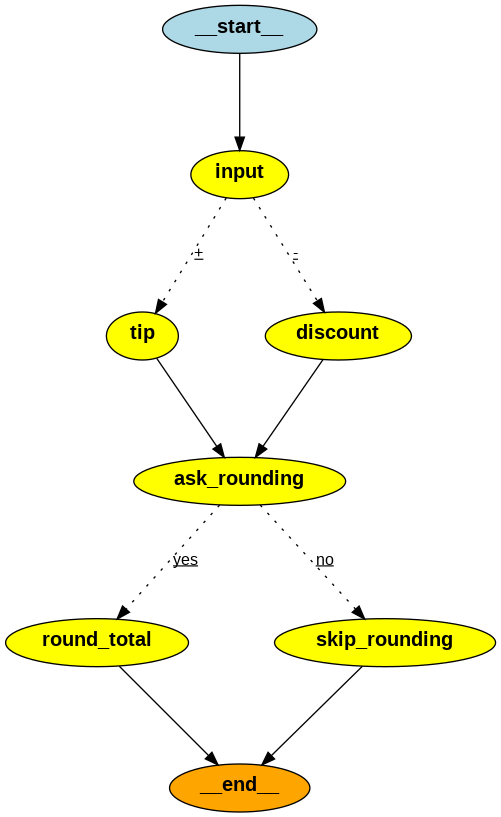

In [20]:
graph =  builder.compile()
from IPython.display import Image, display

# Generate a visualization of the workflow graph
display(Image(graph.get_graph().draw_png()))


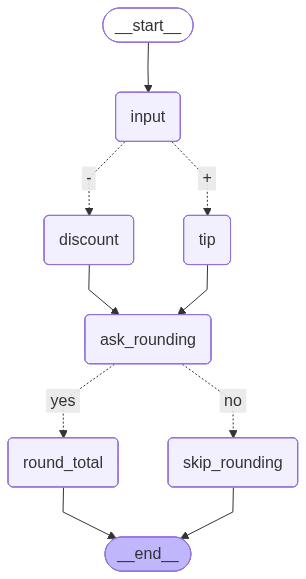

In [21]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [22]:
# invoke with default values
graph.invoke({
    "bill": 0,
    "adjustAmount": 0,
    "operation": "+",
    "round": "no"
})

Enter your total bill amount: 
>>100
Do you want to add a tip(+)or apply a discount(-)?
>>+
Enter the tip or discount amount:
>>10
?? Final total after adding tip: $110.000000
Would you like to round the total to the nearest dollar? (yes/no)
>>yes
?? Final total after rounding: $110.000000


{'bill': 100.0,
 'adjustAmount': 10.0,
 'operation': '+',
 'round': 'yes',
 'final_total': 110}